# Small Dogs of the Dow
### Do the 5 cheapest Dogs — or the Foolish Four — beat the full ten?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The **Dogs of the Dow** is the simple rule of buying the ten highest-yielding Dow stocks each January. A popular 1990s upgrade claimed you could do even better: take only the **five cheapest by share price** (the 'Small Dogs' or 'Low-5'), and better still with the **'Foolish Four'** — skip the #1 cheapest Dog, buy the next four. We test all three variants on the same honest 26-year tape and discover that the Small Dogs look interesting on the surface, the Foolish Four is pure noise, and the 'edge' from a price filter is mostly a crude small-cap tilt you can buy more cheaply.

> 📓 **This is the plain-language layer.** The *t*-stats, multiple-comparison corrections and risk adjustments live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Educational, reproducible research. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (small_dogs/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from small_dogs import data, strategy

AS_OF = "2026-06-13"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
panel = data.load_panel(end=AS_OF, cache_dir=CACHE)
ann = strategy.annual_returns_from_panel(panel, 2000, 2025, cost_bps=20.0)
summ_small = strategy.summarize(ann, col="small_dogs", bench="dow")
summ_dogs  = strategy.summarize(ann, col="dogs", bench="dow")
summ_f4    = strategy.summarize(ann, col="foolish4", bench="dow")
exc_small = (ann["small_dogs"] - ann["dow"]).to_numpy()
exc_dogs  = (ann["dogs"] - ann["dow"]).to_numpy()
exc_f4    = (ann["foolish4"] - ann["dow"]).to_numpy()
hac_small = strategy.hac_tstat(exc_small)
hac_dogs  = strategy.hac_tstat(exc_dogs)
hac_f4    = strategy.hac_tstat(exc_f4)
boot_small = strategy.block_bootstrap_ci(exc_small)
ab_small = strategy.alpha_beta(ann, strat_col="small_dogs", bench_col="dow")
print(f"Dow panel: {panel['prices'].shape[1]} tickers x {len(panel['prices']):,} days  fingerprint={data.fingerprint(panel)}")
print(f"Small Dogs CAGR {summ_small['strat_cagr']*100:.2f}%  vs Dow {summ_small['bench_cagr']*100:.2f}%  gap {summ_small['cagr_gap']*100:+.2f} pts/yr  ({summ_small['n_years']} yrs)")
print(f"Dogs      CAGR {summ_dogs['strat_cagr']*100:.2f}%   HAC t {hac_dogs:+.2f}")
print(f"Small Dogs HAC t {hac_small:+.2f}   alpha {ab_small['alpha']*100:+.2f}%/yr (t {ab_small['alpha_t']:+.2f})   beta {ab_small['beta']:.2f}")
print(f"Foolish 4  HAC t {hac_f4:+.2f}")


$EK: possibly delisted; no price data found  (1d 1927-07-11 -> 2026-06-16)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


$WBA: possibly delisted; no timezone found


Dow panel: 46 tickers x 6,673 days  fingerprint=6dfd9e54cba6
Small Dogs CAGR 10.57%  vs Dow 7.54%  gap +3.04 pts/yr  (26 yrs)
Dogs      CAGR 8.51%   HAC t +0.59
Small Dogs HAC t +1.82   alpha +5.26%/yr (t +2.68)   beta 0.72
Foolish 4  HAC t -0.09


## The answer first

| Question | Answer |
|---|---|
| Did the Small Dogs beat the Dow over 26 honest years? | **Yes, by +3.0 pts/yr** (CAGR **10.57%** vs **7.54%**) |
| Is that lead statistically real? | **Borderline no** — HAC *t* = **1.82** (bar is 2.0); CI **[-0.27%, +5.63%]**, *p* = 0.07 |
| Did the Foolish Four work? | **No** — essentially flat vs the Dow (+0.14 pts/yr, *t* = -0.09) |
| What explains the Small Dogs' edge? | Mostly a **low-price / low-beta tilt** (beta 0.72) — the same thing a small-cap-value ETF gives you cheaply |

## 1 · The claim

Michael O'Higgins showed in *Beating the Dow* (1991) that picking the ten highest-yield Dow stocks each January beat the index. His 'Low-5' variant: of those ten, take only the **five with the lowest absolute share price**. The Motley Fool's 'Foolish Four' (1996) went further: skip #1 cheapest, buy #2-#5. The intuition — low share prices signal beaten-down value — sounds coherent. But there's a catch: the Foolish Four was discovered by looking at a historical table and noting which variant looked best. That is not a discovery; it is a data artefact waiting to collapse.

## 2 · So what?

If a price-filter on top of the Dogs adds genuine value, it's telling you something real about which beaten-down Dow names recover. If it's curve-fitting on a 20-year window, it vanishes the moment you start trading it live — which is exactly what the Motley Fool found in 2000 when they retired the Foolish Four and called it a mistake.

## 3 · How would we even know?

We run all three variants (Dogs-10, Small Dogs-5, Foolish Four) on the **exact same 26-year point-in-time tape** — the same membership timeline from Study 88, the same total-return prices, the same 20 bps/turnover cost, the same DIA benchmark. The only thing that changes each year is *which* of the ten Dogs we hold. Any difference in outcomes is attributable to the sub-selection rule alone.

## 4 · The teardown — let's actually look

Three equity curves, $1 invested in 2000:

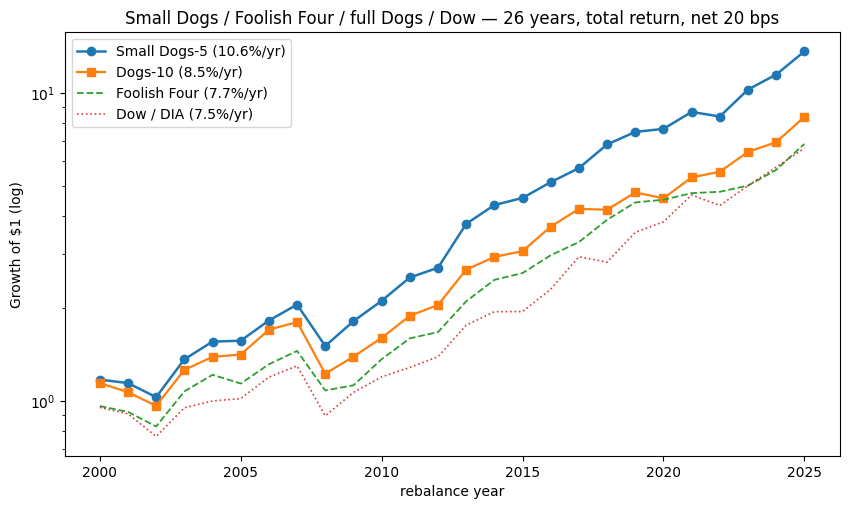

In [2]:
eq_small = (1 + ann['small_dogs']).cumprod()
eq_dogs  = (1 + ann['dogs']).cumprod()
eq_f4    = (1 + ann['foolish4']).cumprod()
eq_dow   = (1 + ann['dow']).cumprod()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(eq_small.index, eq_small.values, marker='o', lw=1.8, label=f"Small Dogs-5 ({summ_small['strat_cagr']*100:.1f}%/yr)")
ax.plot(eq_dogs.index, eq_dogs.values, marker='s', lw=1.6, label=f"Dogs-10 ({summ_dogs['strat_cagr']*100:.1f}%/yr)")
ax.plot(eq_f4.index, eq_f4.values, lw=1.3, ls='--', label=f"Foolish Four ({summ_f4['strat_cagr']*100:.1f}%/yr)")
ax.plot(eq_dow.index, eq_dow.values, lw=1.2, ls=':', alpha=.9, label=f"Dow / DIA ({summ_small['bench_cagr']*100:.1f}%/yr)")
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.set_xlabel('rebalance year')
ax.set_title('Small Dogs / Foolish Four / full Dogs / Dow — 26 years, total return, net 20 bps')
ax.legend(); plt.show()

The Small Dogs line ends highest — $**13.64** vs $**8.36** for the Dogs and $**7.61** for the Dow. But the Foolish Four ($**6.84**) lands *below* the Dow, the strategy that was supposed to be even better. Let's check how much of the Small Dogs' lead is annual-consistent vs lucky streaks.

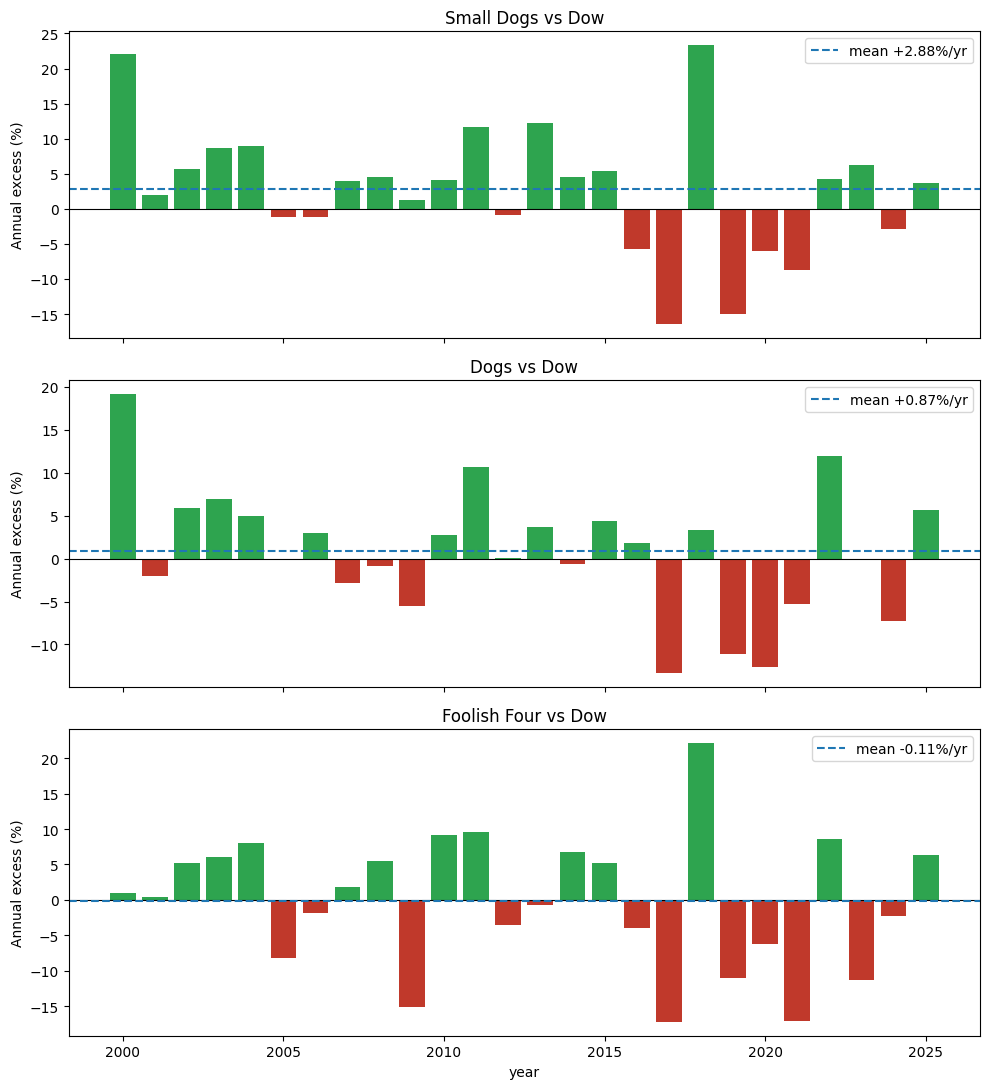

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for ax, col, label in zip(axes,
        ['small_dogs', 'dogs', 'foolish4'],
        ['Small Dogs vs Dow', 'Dogs vs Dow', 'Foolish Four vs Dow']):
    exc = (ann[col] - ann['dow'])*100
    colors = ['#2ea44f' if e > 0 else '#c0392b' for e in exc]
    ax.bar(ann.index, exc, color=colors)
    ax.axhline(0, color='k', lw=.8)
    ax.axhline(exc.mean(), color='C0', ls='--', label=f'mean {exc.mean():+.2f}%/yr')
    ax.set_ylabel('Annual excess (%)')
    ax.set_title(label); ax.legend()
axes[-1].set_xlabel('year'); plt.tight_layout(); plt.show()

Notice the Foolish Four's bars: they bounce around zero with no trend, confirming the strategy is noise. The Small Dogs' bars lean positive but contain several large negative years — the mean is real-looking, but so is the variance around it.

Now what does 'low-priced Dogs' actually buy you in a crisis? Let's check the Jan-2009 basket.

In [4]:
from small_dogs.strategy import trailing_yield
rebal = pd.Timestamp('2008-12-31')
members = data.members_asof(rebal)
yy, pxr = {}, {}
for t in members:
    if t in panel['prices'].columns:
        dv = panel['divs'][t].dropna() if t in panel['divs'].columns else pd.Series(dtype=float)
        v = trailing_yield(panel['prices'][t].dropna(), dv, rebal)
        seg = panel['prices'][t].dropna().loc[:rebal]
        if np.isfinite(v) and v > 0 and not seg.empty:
            yy[t] = v; pxr[t] = float(seg.iloc[-1])
dogs_top10 = sorted(yy, key=lambda k: yy[k], reverse=True)[:10]
by_price = sorted(dogs_top10, key=lambda k: pxr[k])
print('Jan-2009 Dogs basket: yield / share price (cheapest first)')
for t in by_price:
    mark = ' << Small Dog' if t in by_price[:5] else ''
    print(f'  {t:5s}  yield {yy[t]*100:5.1f}%  price ${pxr[t]:7.2f}{mark}')

Jan-2009 Dogs basket: yield / share price (cheapest first)
  DD     yield  17.6%  price $   5.69 << Small Dog
  PFE    yield  15.1%  price $   8.04 << Small Dog
  BAC    yield  20.8%  price $  10.75 << Small Dog
  KFT    yield   9.7%  price $  11.58 << Small Dog
  VZ     yield  12.8%  price $  12.77 << Small Dog
  MRK    yield   9.1%  price $  15.94
  JPM    yield   7.4%  price $  20.44
  AA     yield   7.1%  price $  23.15
  C      yield  22.8%  price $  49.18
  GE     yield  11.1%  price $  53.41


The January-2009 Small Dogs basket is a concentration of financials in free-fall: Citigroup and Bank of America top the yield list (both about to cut dividends to near zero) and are also among the cheapest by share price — so both filters agree on picking the most distressed names. The 'value' signal here is a dividend trap. The Small Dogs didn't just pick beaten-down names; they over-concentrated in them.

## 5 · The verdict

- **Small Dogs beat the Dow by +3.0 pts/yr over 26 years** — but the HAC *t* sits at **1.82**, just below the bar of 2.0 (*p* = 0.07). The CI straddles zero at [-0.27%, +5.63%]. → **Signal: Weak.**
- **The Foolish Four earned nothing** (+0.14 pts/yr, *t* = -0.09) — the skip-the-cheapest quirk was pure curve-fitting. → Bust.
- **The price-filter tilt is a crude small-cap proxy.** A low absolute share price within the Dow 30 is not an independent signal — it is a rough proxy for the size/value factor, replicable far more cheaply with a small-cap-value ETF.
- **Tradability: Mirage.** A 5-name equal-weight basket of the cheapest blue chips is highly concentrated, carries dividend-trap risk (2009 again), and the data-mining history means any statistical flicker is suspect. → **Tradability: Mirage.**

## 6 · Could you actually trade it?

The trade is technically trivial — five blue-chip Dow names, annual rebalance. But the economics don't work: (1) the edge doesn't clear a significance test; (2) it's a 5-name portfolio with massive single-stock risk; (3) the Foolish Four — the variant that attracted real money in the late 1990s — collapsed immediately in live trading; (4) you're buying a small-cap tilt wrapped in a dividend-trap screen. You can own a small-cap-value ETF for 10-15 bps/year without any of these drawbacks.

## 7 · Going further

- Replace absolute price with **market-cap rank** within the Dogs — does the size tilt read cleaner as an explicit factor?
- Apply a **dividend-trap filter** (forward earnings yield or payout-ratio cap) before the price screen — does avoiding the 2009 financials recover a real edge?
- Test the same price-filter idea on a **wider universe** (S&P 100 high-dividend names) to see whether the residual tilt is Dogs-specific or factor-general.
- See [Study 88 — Dogs-of-the-Dow](../../../88-dogs-of-the-dow/) for the parent strategy and the full point-in-time membership teardown.